In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter
from IPython.display import HTML

In [4]:
N = 500
frames = 200
interval = 100

def count_neighbors(world):
    return ( np.roll(world,1,0) + np.roll(world,-1,0) + np.roll(world,1,1) + np.roll(world,-1,1) +
             np.roll(np.roll(world,1,0),1,1) + np.roll(np.roll(world,1,0),-1,1) + 
             np.roll(np.roll(world,-1,0),1,1) + np.roll(np.roll(world,-1,0),-1,1) )

def evolve(world):
    neighbors = count_neighbors(world)
    new_world = np.zeros(world.shape)
    mask = ( (world==1) & ( (neighbors==2) | (neighbors==3) ) ) | ( (world==0) & (neighbors==3) )
    new_world[mask] = 1
    return new_world

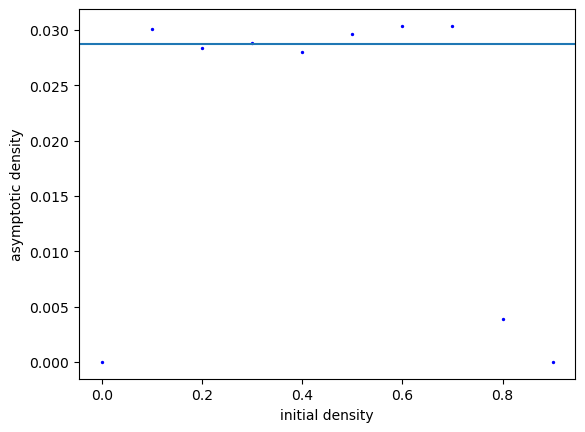

In [10]:
N = 180
T = 4000
trajectories = 7
initial_density = np.arange(0,1,0.1)
asymptotic_density = []
for i_d in initial_density:
    aux_d = 0
    for i in range(trajectories):
        world = world = np.random.random((N,N))
        world[world > i_d] = 0
        world[world != 0] = 1
        for j in range(T):
            world = evolve(world)
        aux_d += (1/trajectories)*np.sum(world==1)/N**2
    asymptotic_density.append(aux_d)
plt.scatter(initial_density, asymptotic_density, s = 2, color = 'blue')
plt.axhline(0.0287)
plt.xlabel('initial density')
plt.ylabel('asymptotic density')
plt.show()

In [20]:
N = 180
T = 4000
trajectories = 5
initial_density = np.arange(0,1,0.1)

asymptotic_density = []
asymptotic_error = []

for i_d in initial_density:

    traj_values = []

    for i in range(trajectories):

        world = np.random.random((N,N))
        world[world > i_d] = 0
        world[world != 0] = 1

        for j in range(T):
            world = evolve(world)

        traj_values.append(np.sum(world==1)/N**2)

    traj_values = np.array(traj_values)

    mean_density = np.mean(traj_values)
    std_density = np.std(traj_values, ddof=1)   # campionaria
    error_density = std_density / np.sqrt(trajectories)

    asymptotic_density.append(mean_density)
    asymptotic_error.append(error_density)


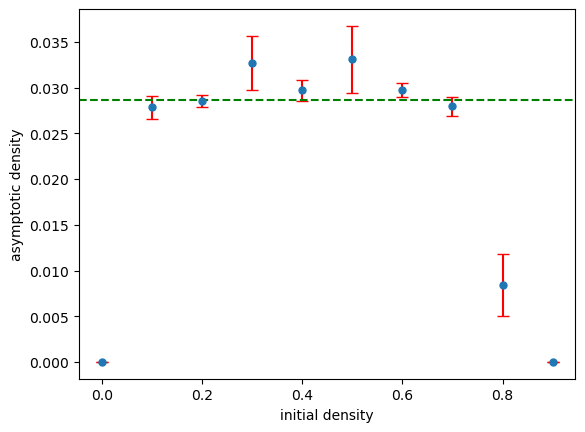

In [21]:
plt.errorbar(initial_density,
             asymptotic_density,
             yerr=asymptotic_error,
             fmt='o',
             markersize=5,
             capsize=4, ecolor = 'r')

plt.axhline(0.0287, linestyle='--', color = 'g')
plt.xlabel('initial density')
plt.ylabel('asymptotic density')
plt.show()


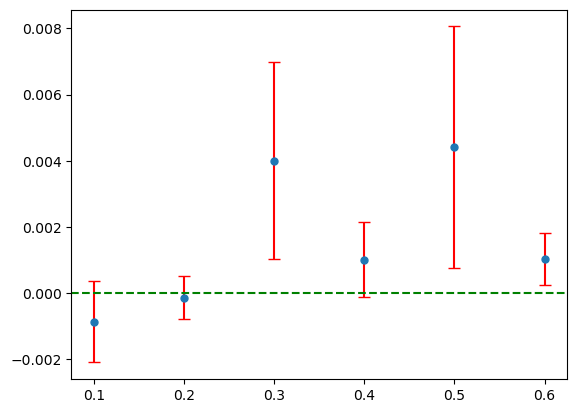

In [32]:
p = np.array(asymptotic_density[1:7])
d = initial_density[1:7]
err = asymptotic_error[1:7]
scarto = p - 0.0287

plt.errorbar(d,
             scarto,
             yerr=err,
             fmt='o',
             markersize=5,
             capsize=4, ecolor = 'r')
plt.axhline(0.0, linestyle='--', color = 'g')
plt.show()

In [10]:
N = 150
T = 9000
trajectories = 7
initial_density = np.arange(0.4,0.6,0.05)

asymptotic_density = []
asymptotic_error = []

for i_d in initial_density:

    traj_values = []

    for i in range(trajectories):

        world = np.random.random((N,N))
        world[world > i_d] = 0
        world[world != 0] = 1

        for j in range(T):
            world = evolve(world)

        traj_values.append(np.sum(world==1)/N**2)

    traj_values = np.array(traj_values)

    mean_density = np.mean(traj_values)
    std_density = np.std(traj_values, ddof=1)   # campionaria
    error_density = std_density / np.sqrt(trajectories)

    asymptotic_density.append(mean_density)
    asymptotic_error.append(error_density)


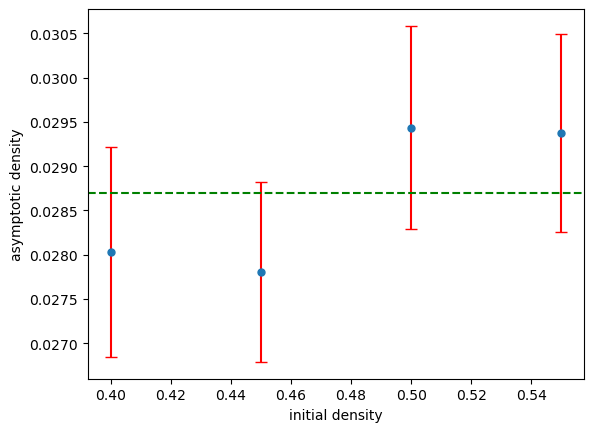

In [11]:
plt.errorbar(initial_density,
             asymptotic_density,
             yerr=asymptotic_error,
             fmt='o',
             markersize=5,
             capsize=4, ecolor = 'r')

plt.axhline(0.0287, linestyle='--', color = 'g')
plt.xlabel('initial density')
plt.ylabel('asymptotic density')
plt.show()
